In [2]:
import pandas as pd
import os
import time
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [3]:
# 1. Initialize a blank BPE tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

# 2. Tell it how to split words (usually at whitespace)
tokenizer.pre_tokenizer = Whitespace()

# 3. Create the trainer
# vocab_size: 5000-10000 is plenty for a keyboard task. 
# It keeps the model lightweight.
trainer = BpeTrainer(vocab_size=10000, show_progress=True, special_tokens=[
    "[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"
])

# 4. Train it on your text file
files = ["training_text.txt"]
tokenizer.train(files, trainer)

# 5. Save it! You'll need these files later for the model
tokenizer.save("tokenizer.json")
print("Tokenizer trained and saved to tokenizer.json")




Tokenizer trained and saved to tokenizer.json


In [4]:
class KeyboardDataset(Dataset):
    def __init__(self, txt_file, tokenizer_path, max_length=32):
        self.tokenizer = Tokenizer.from_file(tokenizer_path)
        self.max_length = max_length
        
        # Load all text and tokenize it into one giant list of IDs
        with open(txt_file, 'r', encoding='utf-8') as f:
            full_text = " ".join([line.strip() for line in f if len(line.strip()) > 2])
        
        self.tokens = self.tokenizer.encode(full_text).ids
        
    def __len__(self):
        # Number of sequences we can create
        return (len(self.tokens) -1)//self.max_length

    def __getitem__(self, idx):
        # Change: Jump by max_length so we don't repeat data 32 times
        start_ptr = idx * self.max_length
        end_ptr = start_ptr + self.max_length

        x = torch.tensor(self.tokens[start_ptr : end_ptr])
        y = torch.tensor(self.tokens[start_ptr + 1 : end_ptr + 1])
        return x, y

In [5]:
# Initialize your training dataset
train_ds = KeyboardDataset("training_text.txt", "tokenizer.json")

# Create the Loader
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=False)

# Test if it works
first_batch = next(iter(train_loader))
inputs, targets = first_batch
print(f"Input shape: {inputs.shape}")   # Should be [64, 32]
print(f"Target shape: {targets.shape}") # Should be [64, 32]

Input shape: torch.Size([64, 32])
Target shape: torch.Size([64, 32])


In [6]:
validation_ds = KeyboardDataset("validation_text.txt", "tokenizer.json")
validation_loader = DataLoader(validation_ds, batch_size=64, num_workers=0, shuffle=False)

first_val_batch = next(iter(validation_loader))
x, y = first_val_batch
print(f"Input shape: {x.shape}")   # Should be [64, 32]
print(f"Target shape: {y.shape}") # Should be [64, 32]

Input shape: torch.Size([64, 32])
Target shape: torch.Size([64, 32])


In [7]:

# 1. Setup Device for M4
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 2. Hyperparameters
vocab_size = 10000  # Your chosen size
n_embd = 256        # Size of the "vector" for each word
n_head = 8          # Number of attention "heads"
n_layer = 4         # Number of transformer blocks
block_size = 32     # Your context length

class Head(nn.Module):
    """ One head of self-attention """
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B,T,head_size)
        q = self.query(x) # (B,T,head_size)
        # Compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        # Perform the weighted aggregation of the values
        v = self.value(x) # (B,T,head_size)
        out = wei @ v # (B, T, head_size)
        return out

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out

class FeedForward(nn.Module):
    """ A simple linear layer followed by a non-linearity """
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class KeyboardTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

# Instantiate the model and move to M4 GPU
model = KeyboardTransformer().to(device)
print(f"Model initialized on {device}")

Model initialized on mps


In [8]:
# 1. Hyperparameters for Training
learning_rate = 3e-4
epochs = 10  # Start with 5 passes through the data
eval_interval = 500 # Check the 'loss' every 500 batches

# 2. Initialize Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


In [9]:

# History storage
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

@torch.no_grad()
def evaluate_model(loader):
    model.eval()
    losses = []
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, loss = model(x, y)
        losses.append(loss.item())
        
        # Calculate Accuracy: compare highest logit to target
        preds = torch.argmax(logits, dim=-1) # (B*T)
        correct += (preds == y.view(-1)).sum().item()
        total += y.numel()
        
    model.train()
    return sum(losses)/len(losses), (correct / total) * 100

print(f"Training started...")

for epoch in range(epochs):
    # Training
    train_epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item()

    # Evaluation
    t_loss, t_acc = evaluate_model(train_loader)
    v_loss, v_acc = evaluate_model(validation_loader)
    
    # Save to history
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    print(f"Epoch {epoch+1}: T-Loss {t_loss:.4f} | V-Loss {v_loss:.4f} | V-Acc {v_acc:.2f}%")

Training started...
Epoch 1: T-Loss 4.4356 | V-Loss 4.4870 | V-Acc 25.32%
Epoch 2: T-Loss 4.0836 | V-Loss 4.2004 | V-Acc 27.52%
Epoch 3: T-Loss 3.8325 | V-Loss 4.0351 | V-Acc 28.62%
Epoch 4: T-Loss 3.6235 | V-Loss 3.9357 | V-Acc 29.29%
Epoch 5: T-Loss 3.4273 | V-Loss 3.8600 | V-Acc 29.75%
Epoch 6: T-Loss 3.2514 | V-Loss 3.8285 | V-Acc 30.33%
Epoch 7: T-Loss 3.0801 | V-Loss 3.8217 | V-Acc 30.03%
Epoch 8: T-Loss 2.9107 | V-Loss 3.8251 | V-Acc 30.50%
Epoch 9: T-Loss 2.7527 | V-Loss 3.8491 | V-Acc 30.11%
Epoch 10: T-Loss 2.6002 | V-Loss 3.8882 | V-Acc 30.25%


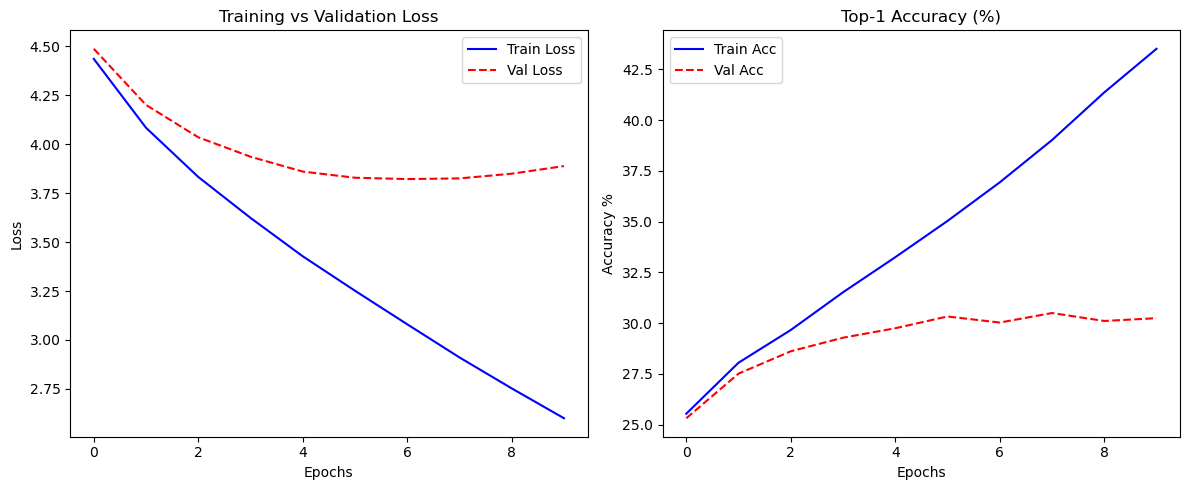

In [10]:
plt.figure(figsize=(12, 5))

# --- Graph 1: Loss ---
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Graph 2: Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='blue')
plt.plot(history['val_acc'], label='Val Acc', color='red', linestyle='--')
plt.title('Top-1 Accuracy (%)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy %')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
def predict_next_words(text, top_k=6):
    model.eval()
    # 1. Tokenize the input
    tokens = tokenizer.encode(text).ids
    # 2. Crop to our block_size (32)
    tokens = tokens[-block_size:]
    tokens_tensor = torch.tensor([tokens]).to(device)
    
    # 3. Get predictions
    with torch.no_grad():
        logits, _ = model(tokens_tensor)
        # We only care about the LAST predicted token
        last_word_logits = logits[0, -1, :]
        
        # 4. Get the Top K probabilities
        probs = F.softmax(last_word_logits, dim=-1)
        top_probs, top_indices = torch.topk(probs, top_k)
        
    # 5. Convert IDs back to words
    suggestions = []
    for i in range(top_k):
        word = tokenizer.decode([top_indices[i].item()])
        suggestions.append(word)
        
    return suggestions

# --- TRY IT OUT ---
my_sentence = " I want" # Try different inputs here!
results = predict_next_words(my_sentence)
print(f"Input: {my_sentence}")
print(f"Suggestions: {results}")

Input:  I want
Suggestions: ['to', 'a', '.', 'the', 'my', 'some']


In [13]:
# Save the PyTorch model weights
torch.save(model.state_dict(), "keyboard_model.pth")


print("Both files saved successfully for production deployment!")

Both files saved successfully for production deployment!
